# Results

1. 固定 `epslion`
   - `alpha` 变化下的结果 error 和 space 结果
   - `stream length` 变化下 error 和 space 结果
2.  `epsilon`变化结果
3. `logical space`变化结果
3. 固定 logical space
   - `alpha` 变化下的结果 error
   - `stream length` 变化下 error

实验结果：

- `report/tables/project_required_expanded_merged/results.jsonl`
- `report/tables/project_required_expanded_merged/summary.csv`


In [ ]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
SRC = ROOT / 'src'
VENDOR = ROOT / '.vendor'

if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
if VENDOR.exists() and str(VENDOR) not in sys.path:
    sys.path.append(str(VENDOR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import ScalarFormatter

plt.style.use('default')
plt.rcdefaults()
plt.rcParams['figure.figsize'] = (18, 5)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['figure.edgecolor'] = 'white'
plt.rcParams['savefig.facecolor'] = 'white'
plt.rcParams['savefig.edgecolor'] = 'white'
plt.rcParams['savefig.transparent'] = False
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'
plt.rcParams['text.color'] = 'black'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.22
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['legend.fontsize'] = 10

FIG_DIR = ROOT / 'report' / 'figures' / 'project_required_expanded'
FIG_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_PATH = ROOT / 'report' / 'tables' / 'project_required_expanded_merged' / 'results.jsonl'
SUMMARY_PATH = ROOT / 'report' / 'tables' / 'project_required_expanded_merged' / 'summary.csv'
EPS_RESULTS_PATH = ROOT / 'report' / 'tables' / 'epsilon_sweep_merged' / 'results.jsonl'
EPS_SUMMARY_PATH = ROOT / 'report' / 'tables' / 'epsilon_sweep_merged' / 'summary.csv'
SPACE_RESULTS_PATH = ROOT / 'report' / 'tables' / 'equal_logical_space_merged' / 'results.jsonl'
SPACE_SUMMARY_PATH = ROOT / 'report' / 'tables' / 'equal_logical_space_merged' / 'summary.csv'

print('ROOT =', ROOT)
print('RESULTS_PATH exists =', RESULTS_PATH.exists())
print('SUMMARY_PATH exists =', SUMMARY_PATH.exists())
print('EPS_RESULTS_PATH exists =', EPS_RESULTS_PATH.exists())
print('EPS_SUMMARY_PATH exists =', EPS_SUMMARY_PATH.exists())
print('SPACE_RESULTS_PATH exists =', SPACE_RESULTS_PATH.exists())
print('SPACE_SUMMARY_PATH exists =', SPACE_SUMMARY_PATH.exists())
print('FIG_DIR =', FIG_DIR)

ROOT = /home/ypwang/5020-Project
RESULTS_PATH exists = True
SUMMARY_PATH exists = True
EPS_RESULTS_PATH exists = True
EPS_SUMMARY_PATH exists = True
SPACE_RESULTS_PATH exists = True
SPACE_SUMMARY_PATH exists = True
FIG_DIR = /home/ypwang/5020-Project/report/figures/project_required_expanded


In [36]:
def _normalize_result_frame(frame):
    frame = frame.copy()
    frame['alpha'] = frame['alpha'].astype(float)
    frame['final_f1_star'] = frame['final_f1_star'].astype(int)
    frame['stream_length'] = frame['stream_length'].astype(int)
    frame['logical_size'] = frame['logical_size'].astype(float)
    frame['avg_norm_abs_error'] = frame['avg_norm_abs_error'].astype(float)
    frame['avg_relative_error'] = frame['avg_relative_error'].astype(float)
    if 'algorithm_variant' not in frame.columns:
        frame['algorithm_variant'] = frame['algorithm']
    if 'config_epsilon' not in frame.columns:
        frame['config_epsilon'] = np.nan
    else:
        frame['config_epsilon'] = pd.to_numeric(frame['config_epsilon'], errors='coerce')
    if 'config_target_logical_size' not in frame.columns:
        frame['config_target_logical_size'] = np.nan
    else:
        frame['config_target_logical_size'] = pd.to_numeric(frame['config_target_logical_size'], errors='coerce')
    return frame


def _normalize_summary_frame(frame):
    frame = frame.copy()
    frame['alpha'] = frame['alpha'].astype(float)
    frame['final_f1_star'] = frame['final_f1_star'].astype(int)
    if 'config_epsilon' in frame.columns:
        frame['config_epsilon'] = pd.to_numeric(frame['config_epsilon'], errors='coerce')
    if 'config_target_logical_size' in frame.columns:
        frame['config_target_logical_size'] = pd.to_numeric(frame['config_target_logical_size'], errors='coerce')
    return frame


results = _normalize_result_frame(pd.read_json(RESULTS_PATH, lines=True))
summary = _normalize_summary_frame(pd.read_csv(SUMMARY_PATH))
epsilon_results = _normalize_result_frame(pd.read_json(EPS_RESULTS_PATH, lines=True))
epsilon_summary = _normalize_summary_frame(pd.read_csv(EPS_SUMMARY_PATH))
equal_space_results = _normalize_result_frame(pd.read_json(SPACE_RESULTS_PATH, lines=True))
equal_space_summary = _normalize_summary_frame(pd.read_csv(SPACE_SUMMARY_PATH))

algorithm_order = ['double_mg', 'double_ss', 'integrated_sspm', 'count_min', 'count_sketch']
dataset_order = ['kosarak', 'zipf', 'uniform']
marker_map = {
    'double_mg': 'o',
    'double_ss': 's',
    'integrated_sspm': '^',
    'count_min': 'D',
    'count_sketch': 'X',
}
color_map = {
    'double_mg': '#1f77b4',
    'double_ss': '#ff7f0e',
    'integrated_sspm': '#2ca02c',
    'count_min': '#d62728',
    'count_sketch': '#9467bd',
}

print('rows in results =', len(results))
print('rows in epsilon_results =', len(epsilon_results))
print('rows in equal_space_results =', len(equal_space_results))
print('algorithms =', sorted(results['algorithm'].unique()))
print('families =', sorted(results['family'].unique()))
print('alpha values =', sorted(results['alpha'].unique()))
print('F1* values =', sorted(results['final_f1_star'].unique()))
print('epsilon values =', sorted(value for value in epsilon_results['config_epsilon'].dropna().unique()))
print('equal-space budgets =', sorted(int(value) for value in equal_space_results['config_target_logical_size'].dropna().unique()))

rows in results = 360
rows in epsilon_results = 1080
rows in equal_space_results = 1440
algorithms = ['count_min', 'count_sketch', 'double_mg', 'double_ss', 'integrated_sspm']
families = ['kosarak', 'uniform', 'zipf']
alpha values = [np.float64(1.5), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(6.0), np.float64(8.0)]
F1* values = [np.int64(50000), np.int64(100000), np.int64(200000), np.int64(500000)]
epsilon values = [np.float64(0.01), np.float64(0.05), np.float64(0.1)]
equal-space budgets = [300, 600, 1200, 2400]


In [37]:
coverage = (
    results.groupby(['family', 'final_f1_star', 'alpha'])['algorithm']
    .count()
    .reset_index(name='num_algorithms')
    .sort_values(['family', 'final_f1_star', 'alpha'])
)
coverage.head(20)

,family,final_f1_star,alpha,num_algorithms
0,kosarak,50000,1.5,5
1,kosarak,50000,2.0,5
2,kosarak,50000,3.0,5
3,kosarak,50000,4.0,5
4,kosarak,50000,6.0,5
5,kosarak,50000,8.0,5
6,kosarak,100000,1.5,5
7,kosarak,100000,2.0,5
8,kosarak,100000,3.0,5
9,kosarak,100000,4.0,5


## Helper Functions

In [49]:
def _sorted_algorithms(values):
    return [name for name in algorithm_order if name in values]


def _set_white_background(fig, axes):
    fig.patch.set_facecolor('white')
    for ax in np.ravel(axes):
        ax.set_facecolor('white')


def _line_handles(algorithms):
    return [
        Line2D([0], [0], color=color_map[algo], marker=marker_map[algo], linewidth=2, markersize=7, label=algo)
        for algo in algorithms
    ]


def _type_handles():
    return [
        Line2D([0], [0], color='black', linewidth=2, marker='o', label='error (line)'),
        Patch(facecolor='gray', edgecolor='gray', alpha=0.2, label='space (bar)'),
    ]


def _apply_sci(ax, axis='y'):
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((0, 0))
    formatter.set_useOffset(True)
    if axis == 'x':
        ax.xaxis.set_major_formatter(formatter)
    else:
        ax.yaxis.set_major_formatter(formatter)
    ax.ticklabel_format(axis=axis, style='sci', scilimits=(0, 0), useMathText=True)


def _apply_log_budget_x(ax, budgets):
    ax.set_xscale('log', base=2)
    ax.set_xticks(budgets)
    ax.xaxis.set_major_formatter(ScalarFormatter())


def _grouped_bar_width(values, n_series, group_fraction=0.72):
    values = np.asarray(values, dtype=float)
    if len(values) <= 1:
        base_gap = values[0] if len(values) else 1.0
    else:
        base_gap = np.min(np.diff(np.sort(values)))
    return group_fraction * base_gap / max(n_series, 1)


def _family_title(family):
    return {
        'kosarak': 'Kosarak',
        'zipf': 'Zipf',
        'uniform': 'Uniform',
    }.get(family, family)


def _metric_title(metric):
    titles = {
        'avg_norm_abs_error': 'MAE',
        'avg_relative_error': 'MRE',
    }
    return titles.get(metric, metric.replace('_', ' '))


def _metric_ylabel(metric, log_scale=False):
    label = {
        'avg_norm_abs_error': 'MAE',
        'avg_relative_error': 'MRE',
    }.get(metric, metric.replace('_', ' '))
    if log_scale:
        return f'{label}'
    return label


def plot_triptych_alpha(df, final_f1=100000, error_metric='avg_norm_abs_error', space_metric='logical_size', save_name=None):
    fig, axes = plt.subplots(1, 3, figsize=(19, 5.4), facecolor='white')
    _set_white_background(fig, axes)
    algorithms = _sorted_algorithms(df['algorithm'].unique())

    for ax, family in zip(axes, dataset_order):
        subset = df[(df['family'] == family) & (df['final_f1_star'] == final_f1)].copy()
        subset = subset.sort_values('alpha')
        alphas = sorted(subset['alpha'].unique())
        x = np.arange(len(alphas), dtype=float)
        bar_width = 0.13
        ax2 = ax.twinx()

        for idx, algorithm in enumerate(algorithms):
            algo_df = subset[subset['algorithm'] == algorithm].sort_values('alpha')
            err_values = [algo_df.loc[algo_df['alpha'] == alpha, error_metric].iloc[0] for alpha in alphas]
            space_values = [algo_df.loc[algo_df['alpha'] == alpha, space_metric].iloc[0] for alpha in alphas]

            offsets = x + (idx - (len(algorithms) - 1) / 2) * bar_width
            ax2.bar(
                offsets,
                space_values,
                width=bar_width,
                color=color_map[algorithm],
                edgecolor=color_map[algorithm],
                alpha=0.18,
                linewidth=1.0,
                zorder=1,
            )
            ax.plot(
                x,
                err_values,
                color=color_map[algorithm],
                marker=marker_map[algorithm],
                linewidth=2,
                markersize=6,
                zorder=3,
            )

        ax.set_title(_family_title(family))
        ax.set_xticks(x)
        ax.set_xticklabels([str(alpha) for alpha in alphas])
        ax.set_xlabel('alpha')
        ax.set_ylabel(_metric_ylabel(error_metric, log_scale=True))
        ax.set_yscale('log')
        _apply_sci(ax2, 'y')
        if family == dataset_order[-1]:
            ax2.set_ylabel('logical size')

    handles = _type_handles() + _line_handles(algorithms)
    fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1.08), ncol=4)
    fig.suptitle(f'Alpha sweep: {_metric_title(error_metric)} with space bars (F1*={final_f1})', y=1.16)
    plt.tight_layout()
    if save_name:
        plt.savefig(FIG_DIR / save_name, dpi=220, bbox_inches='tight', facecolor='white', edgecolor='white')
    plt.show()


def plot_triptych_stream_length(df, alpha=4.0, error_metric='avg_norm_abs_error', space_metric='logical_size', save_name=None):
    fig, axes = plt.subplots(1, 3, figsize=(19, 5.4), facecolor='white')
    _set_white_background(fig, axes)
    algorithms = _sorted_algorithms(df['algorithm'].unique())

    for ax, family in zip(axes, dataset_order):
        subset = df[(df['family'] == family) & (df['alpha'] == alpha)].copy()
        subset = subset.sort_values('stream_length')
        stream_lengths = np.array(sorted(subset['stream_length'].unique()), dtype=float)
        bar_width = _grouped_bar_width(stream_lengths, len(algorithms))
        ax2 = ax.twinx()

        for idx, algorithm in enumerate(algorithms):
            algo_df = subset[subset['algorithm'] == algorithm].sort_values('stream_length')
            err_values = [algo_df.loc[algo_df['stream_length'] == length, error_metric].iloc[0] for length in stream_lengths]
            space_values = [algo_df.loc[algo_df['stream_length'] == length, space_metric].iloc[0] for length in stream_lengths]

            offsets = stream_lengths + (idx - (len(algorithms) - 1) / 2) * bar_width
            ax2.bar(
                offsets,
                space_values,
                width=bar_width,
                color=color_map[algorithm],
                edgecolor=color_map[algorithm],
                alpha=0.18,
                linewidth=1.0,
                zorder=1,
            )
            ax.plot(
                stream_lengths,
                err_values,
                color=color_map[algorithm],
                marker=marker_map[algorithm],
                linewidth=2,
                markersize=6,
                zorder=3,
            )

        ax.set_title(_family_title(family))
        ax.set_xticks(stream_lengths)
        ax.set_xlabel('stream length')
        ax.set_ylabel(_metric_ylabel(error_metric))
        _apply_sci(ax, 'x')
        _apply_sci(ax, 'y')
        _apply_sci(ax2, 'y')
        ax.margins(x=0.08)
        if family == dataset_order[-1]:
            ax2.set_ylabel('logical size')

    handles = _type_handles() + _line_handles(algorithms)
    fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1.08), ncol=4)
    fig.suptitle(f'Stream-length sweep: {_metric_title(error_metric)} with space bars (alpha={alpha})', y=1.16)
    plt.tight_layout()
    if save_name:
        plt.savefig(FIG_DIR / save_name, dpi=220, bbox_inches='tight', facecolor='white', edgecolor='white')
    plt.show()


def plot_triptych_epsilon(df, final_f1=100000, alpha=4.0, error_metric='avg_norm_abs_error', space_metric='logical_size', save_name=None):
    fig, axes = plt.subplots(1, 3, figsize=(19, 5.4), facecolor='white')
    _set_white_background(fig, axes)
    algorithms = _sorted_algorithms(df['algorithm'].unique())

    for ax, family in zip(axes, dataset_order):
        subset = df[(df['family'] == family) & (df['final_f1_star'] == final_f1) & (df['alpha'] == alpha)].copy()
        subset = subset.sort_values(['config_epsilon', 'algorithm'])
        epsilons = sorted(value for value in subset['config_epsilon'].dropna().unique())
        x = np.arange(len(epsilons), dtype=float)
        bar_width = 0.13
        ax2 = ax.twinx()

        for idx, algorithm in enumerate(algorithms):
            algo_df = subset[subset['algorithm'] == algorithm].sort_values('config_epsilon')
            err_values = [algo_df.loc[algo_df['config_epsilon'] == epsilon, error_metric].iloc[0] for epsilon in epsilons]
            space_values = [algo_df.loc[algo_df['config_epsilon'] == epsilon, space_metric].iloc[0] for epsilon in epsilons]

            offsets = x + (idx - (len(algorithms) - 1) / 2) * bar_width
            ax2.bar(
                offsets,
                space_values,
                width=bar_width,
                color=color_map[algorithm],
                edgecolor=color_map[algorithm],
                alpha=0.18,
                linewidth=1.0,
                zorder=1,
            )
            ax.plot(
                x,
                err_values,
                color=color_map[algorithm],
                marker=marker_map[algorithm],
                linewidth=2,
                markersize=6,
                zorder=3,
            )

        ax.set_title(_family_title(family))
        ax.set_xticks(x)
        ax.set_xticklabels([f'{epsilon:g}' for epsilon in epsilons])
        ax.set_xlabel('epsilon')
        ax.set_ylabel(_metric_ylabel(error_metric))
        _apply_sci(ax, 'y')
        _apply_sci(ax2, 'y')
        if family == dataset_order[-1]:
            ax2.set_ylabel('logical size')

    handles = _type_handles() + _line_handles(algorithms)
    fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1.08), ncol=4)
    fig.suptitle(f'Epsilon sweep: {_metric_title(error_metric)} with space bars (alpha={alpha}, F1*={final_f1})', y=1.16)
    plt.tight_layout()
    if save_name:
        plt.savefig(FIG_DIR / save_name, dpi=220, bbox_inches='tight', facecolor='white', edgecolor='white')
    plt.show()


def plot_triptych_equal_space(df, final_f1=100000, alpha=4.0, error_metric='avg_norm_abs_error', save_name=None):
    fig, axes = plt.subplots(1, 3, figsize=(19, 5.4), facecolor='white')
    _set_white_background(fig, axes)
    algorithms = _sorted_algorithms(df['algorithm'].unique())

    for ax, family in zip(axes, dataset_order):
        subset = df[(df['family'] == family) & (df['final_f1_star'] == final_f1) & (df['alpha'] == alpha)].copy()
        subset['space_budget'] = subset['config_target_logical_size'].fillna(subset['logical_size']).astype(float)
        subset = subset.sort_values(['space_budget', 'algorithm'])
        budgets = sorted(value for value in subset['space_budget'].dropna().unique())

        for algorithm in algorithms:
            algo_df = subset[subset['algorithm'] == algorithm].sort_values('space_budget')
            err_values = [algo_df.loc[algo_df['space_budget'] == budget, error_metric].iloc[0] for budget in budgets]
            ax.plot(
                budgets,
                err_values,
                color=color_map[algorithm],
                marker=marker_map[algorithm],
                linewidth=2,
                markersize=6,
                zorder=3,
            )

        ax.set_title(_family_title(family))
        _apply_log_budget_x(ax, budgets)
        ax.set_xlabel('logical size budget')
        ax.set_ylabel(_metric_ylabel(error_metric))
        _apply_sci(ax, 'y')

    handles = _line_handles(algorithms)
    fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1.08), ncol=5)
    fig.suptitle(f'Equal logical space: {_metric_title(error_metric)} comparison (alpha={alpha}, F1*={final_f1})', y=1.16)
    plt.tight_layout()
    if save_name:
        plt.savefig(FIG_DIR / save_name, dpi=220, bbox_inches='tight', facecolor='white', edgecolor='white')
    plt.show()


def plot_triptych_equal_space_alpha(df, logical_size=1200, final_f1=100000, error_metric='avg_norm_abs_error', save_name=None):
    fig, axes = plt.subplots(1, 3, figsize=(19, 5.4), facecolor='white')
    _set_white_background(fig, axes)
    algorithms = _sorted_algorithms(df['algorithm'].unique())

    for ax, family in zip(axes, dataset_order):
        subset = df[(df['family'] == family) & (df['final_f1_star'] == final_f1)].copy()
        subset['space_budget'] = subset['config_target_logical_size'].fillna(subset['logical_size']).astype(float)
        subset = subset[np.isclose(subset['space_budget'], logical_size)].sort_values(['alpha', 'algorithm'])
        alphas = sorted(value for value in subset['alpha'].dropna().unique())
        x = np.arange(len(alphas), dtype=float)

        for algorithm in algorithms:
            algo_df = subset[subset['algorithm'] == algorithm].sort_values('alpha')
            err_values = [algo_df.loc[algo_df['alpha'] == alpha, error_metric].iloc[0] for alpha in alphas]
            ax.plot(
                x,
                err_values,
                color=color_map[algorithm],
                marker=marker_map[algorithm],
                linewidth=2,
                markersize=6,
                zorder=3,
            )

        ax.set_title(_family_title(family))
        ax.set_xticks(x)
        ax.set_xticklabels([str(alpha) for alpha in alphas])
        ax.set_xlabel('alpha')
        ax.set_ylabel(_metric_ylabel(error_metric))
        _apply_sci(ax, 'y')

    handles = _line_handles(algorithms)
    fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1.08), ncol=5)
    fig.suptitle(f'Equal logical space alpha sweep: {_metric_title(error_metric)} (L={int(logical_size)}, F1*={final_f1})', y=1.16)
    plt.tight_layout()
    if save_name:
        plt.savefig(FIG_DIR / save_name, dpi=220, bbox_inches='tight', facecolor='white', edgecolor='white')
    plt.show()


def plot_triptych_equal_space_stream_length(df, logical_size=1200, alpha=4.0, error_metric='avg_norm_abs_error', save_name=None):
    fig, axes = plt.subplots(1, 3, figsize=(19, 5.4), facecolor='white')
    _set_white_background(fig, axes)
    algorithms = _sorted_algorithms(df['algorithm'].unique())

    for ax, family in zip(axes, dataset_order):
        subset = df[(df['family'] == family) & (df['alpha'] == alpha)].copy()
        subset['space_budget'] = subset['config_target_logical_size'].fillna(subset['logical_size']).astype(float)
        subset = subset[np.isclose(subset['space_budget'], logical_size)].sort_values(['stream_length', 'algorithm'])
        stream_lengths = np.array(sorted(value for value in subset['stream_length'].dropna().unique()), dtype=float)

        for algorithm in algorithms:
            algo_df = subset[subset['algorithm'] == algorithm].sort_values('stream_length')
            err_values = [algo_df.loc[algo_df['stream_length'] == length, error_metric].iloc[0] for length in stream_lengths]
            ax.plot(
                stream_lengths,
                err_values,
                color=color_map[algorithm],
                marker=marker_map[algorithm],
                linewidth=2,
                markersize=6,
                zorder=3,
            )

        ax.set_title(_family_title(family))
        ax.set_xticks(stream_lengths)
        ax.set_xlabel('stream length')
        ax.set_ylabel(_metric_ylabel(error_metric))
        _apply_sci(ax, 'x')
        _apply_sci(ax, 'y')
        ax.margins(x=0.08)

    handles = _line_handles(algorithms)
    fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1.08), ncol=5)
    fig.suptitle(f'Equal logical space stream-length sweep: {_metric_title(error_metric)} (L={int(logical_size)}, alpha={alpha})', y=1.16)
    plt.tight_layout()
    if save_name:
        plt.savefig(FIG_DIR / save_name, dpi=220, bbox_inches='tight', facecolor='white', edgecolor='white')
    plt.show()

## 1.1 Alpha Sweep (same eps)


每个子图中：
- 折线：error
- 柱状图：space

这里固定 `F1*=100000`。

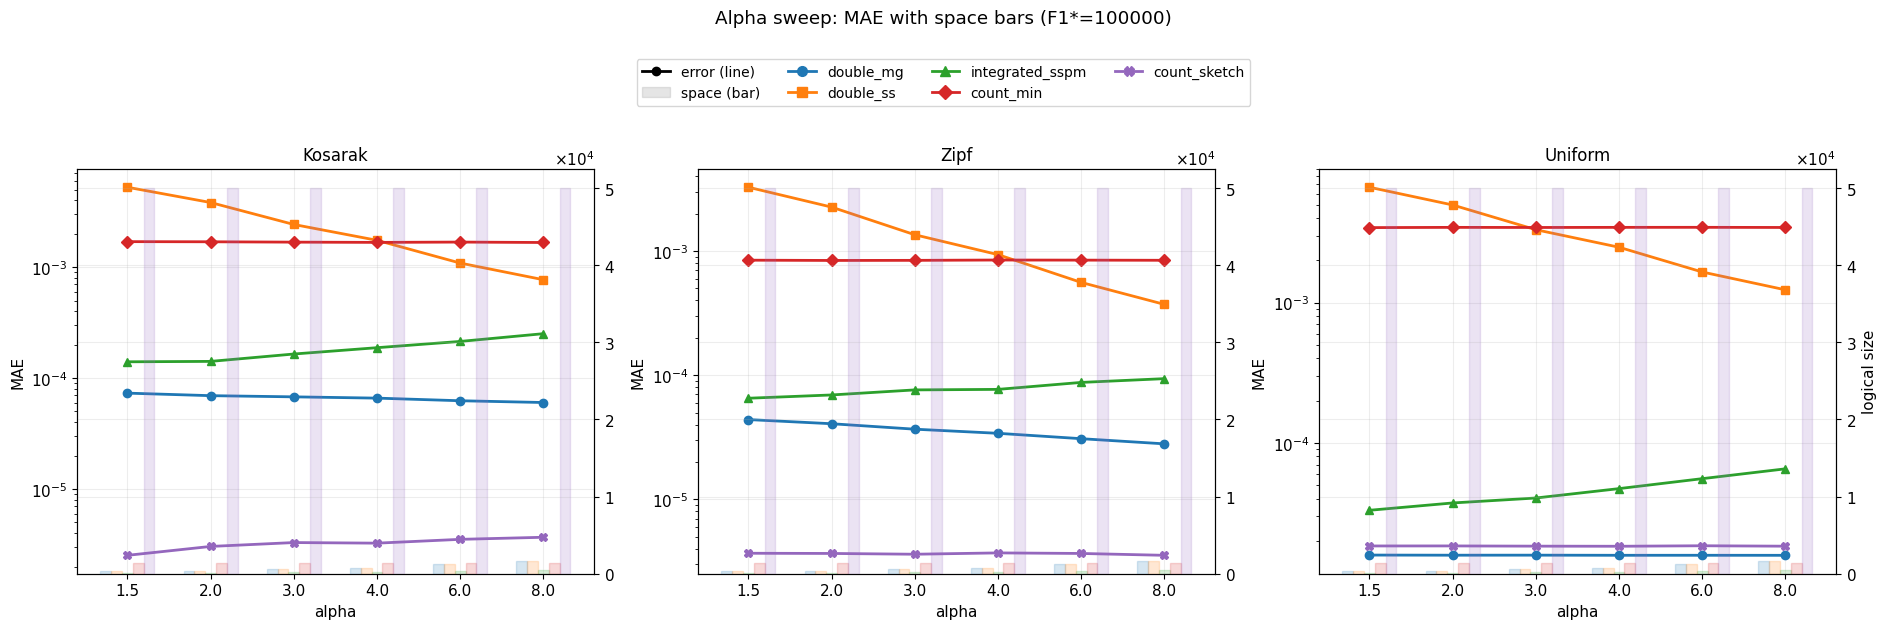

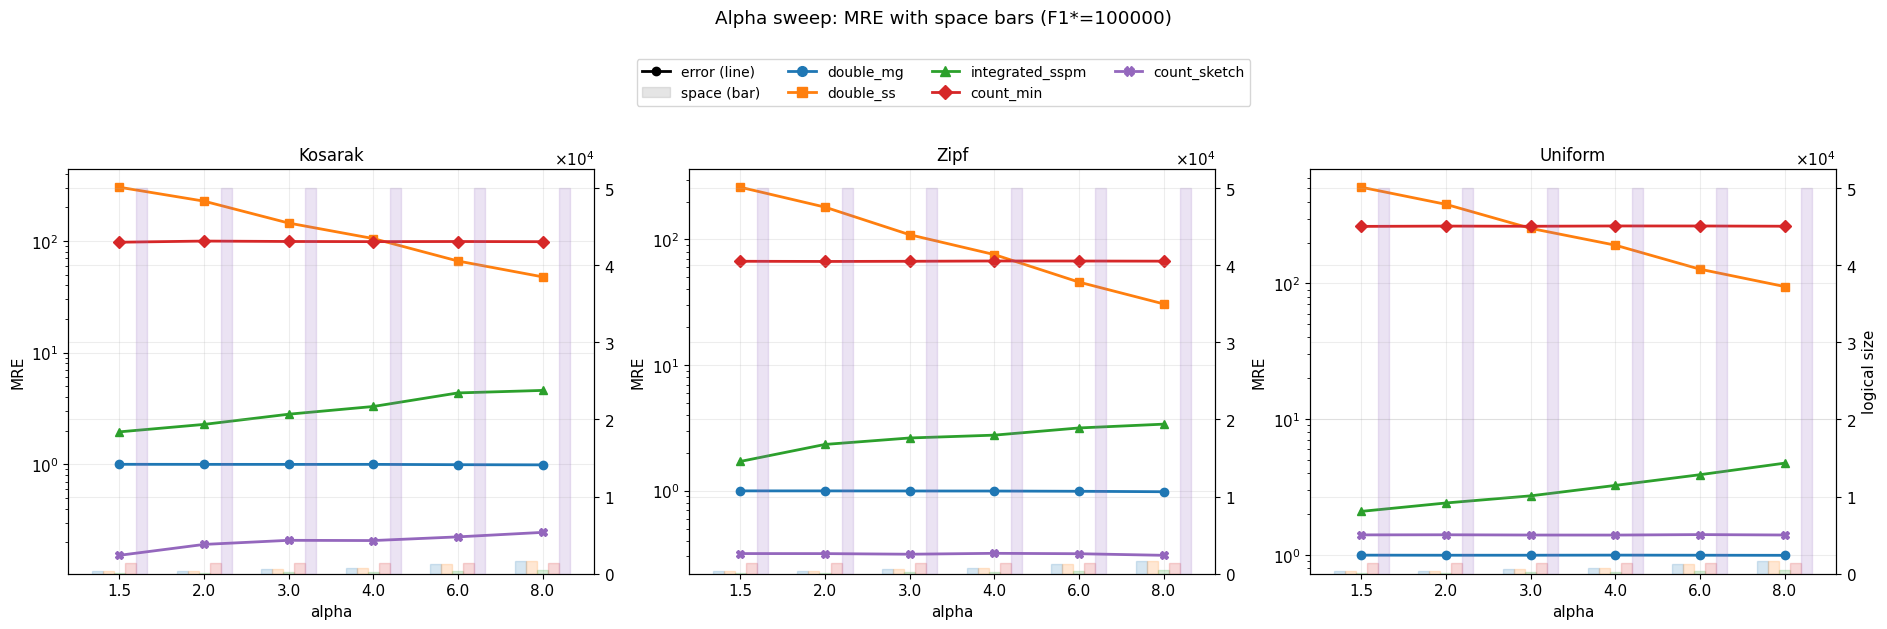

In [50]:
alpha_f1 = 100000
plot_triptych_alpha(
    results,
    final_f1=alpha_f1,
    error_metric='avg_norm_abs_error',
    space_metric='logical_size',
    save_name='alpha_triptych_error_space.png',
)
plot_triptych_alpha(
    results,
    final_f1=alpha_f1,
    error_metric='avg_relative_error',
    space_metric='logical_size',
    save_name='alpha_triptych_relative_error_space.png',
)

## 1.2 Stream-Length Sweep (same eps) 

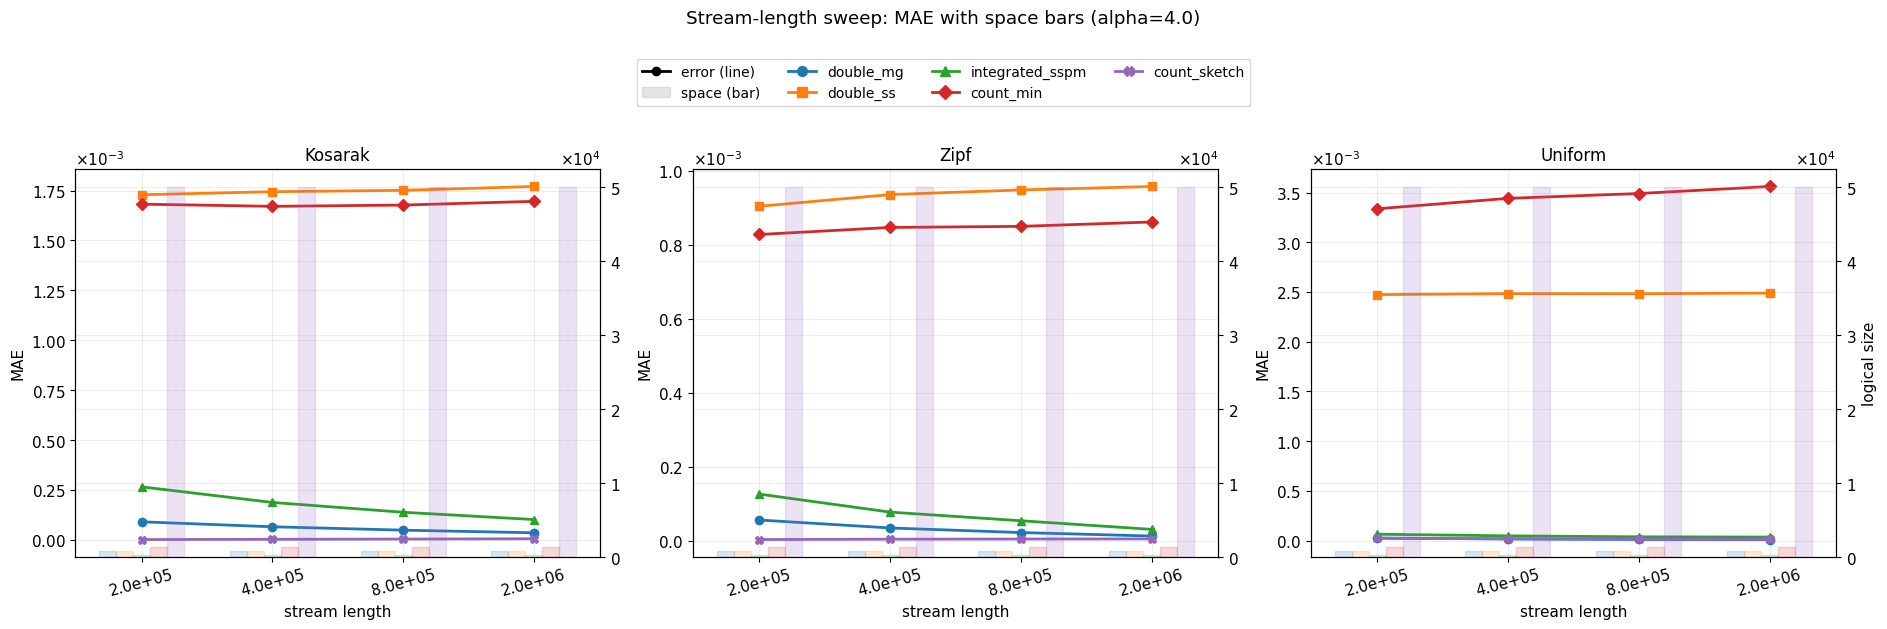

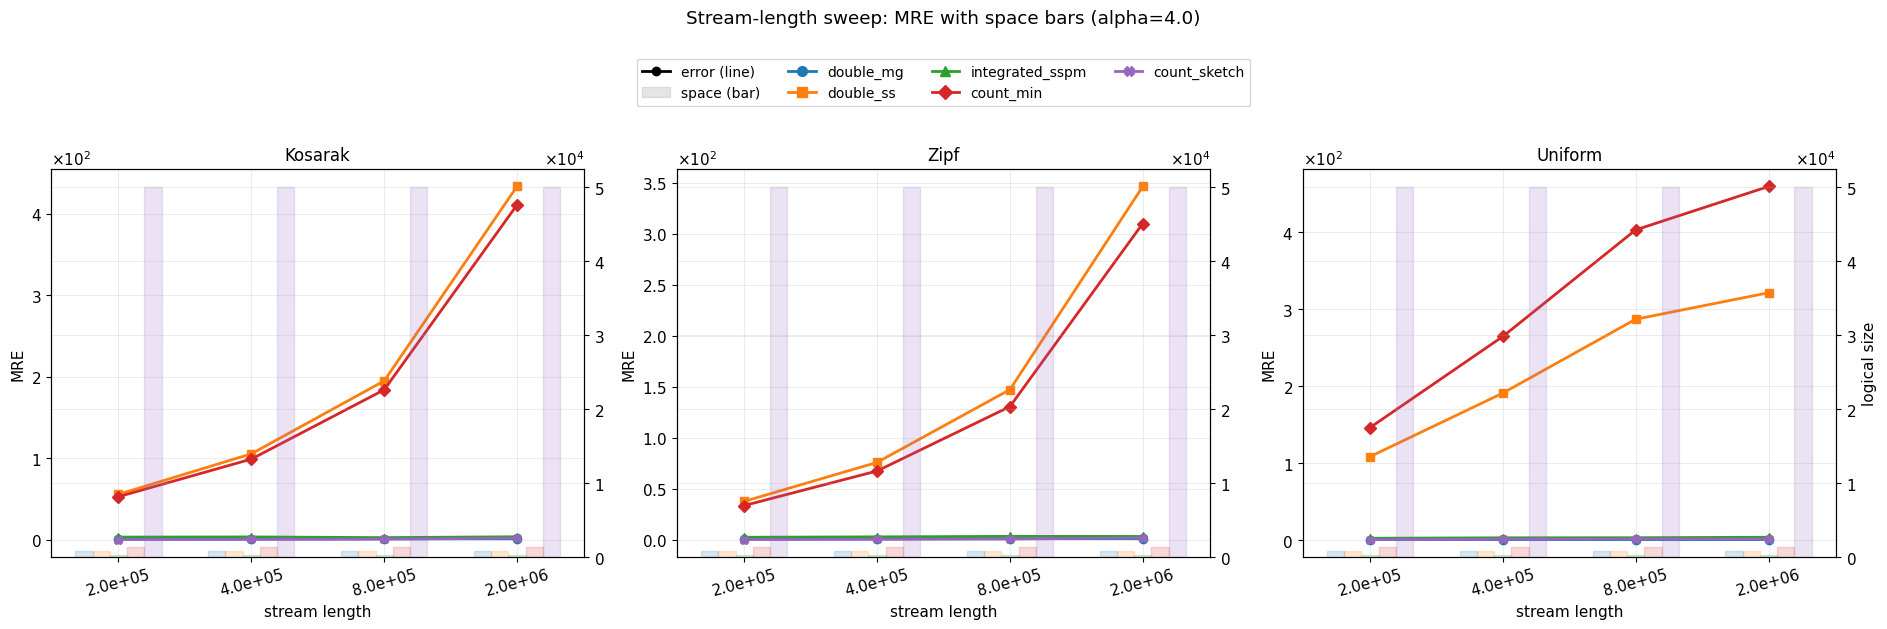

In [55]:
stream_alpha = 4.0  # 可以改成 2.0, 4.0, 8.0 再重新运行
plot_triptych_stream_length(
    results,
    alpha=stream_alpha,
    
    error_metric='avg_norm_abs_error',
    space_metric='logical_size',
    save_name=f'stream_length_triptych_error_space_alpha_{str(stream_alpha).replace('.', 'p')}.png',
)
plot_triptych_stream_length(
    results,
    alpha=stream_alpha,
    error_metric='avg_relative_error',
    space_metric='logical_size',
    save_name=f'stream_length_triptych_relative_error_space_alpha_{str(stream_alpha).replace('.', 'p')}.png',
)

## 2. Epsilon Sweep

补充实验一：固定 `F1*=100000` 和一个 `alpha`，比较 `epsilon = 0.01 / 0.05 / 0.1` 时各算法的 error 和 space。

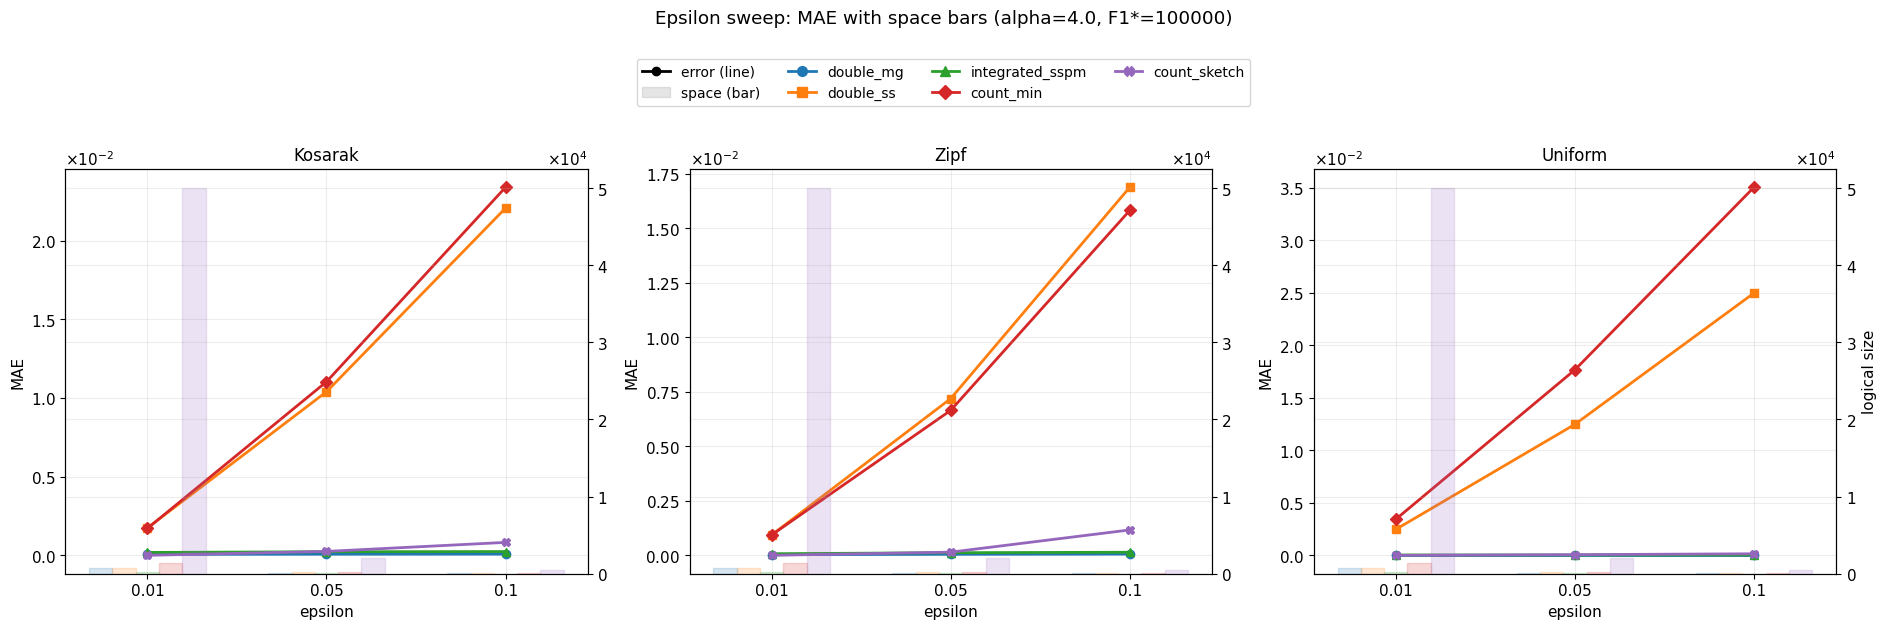

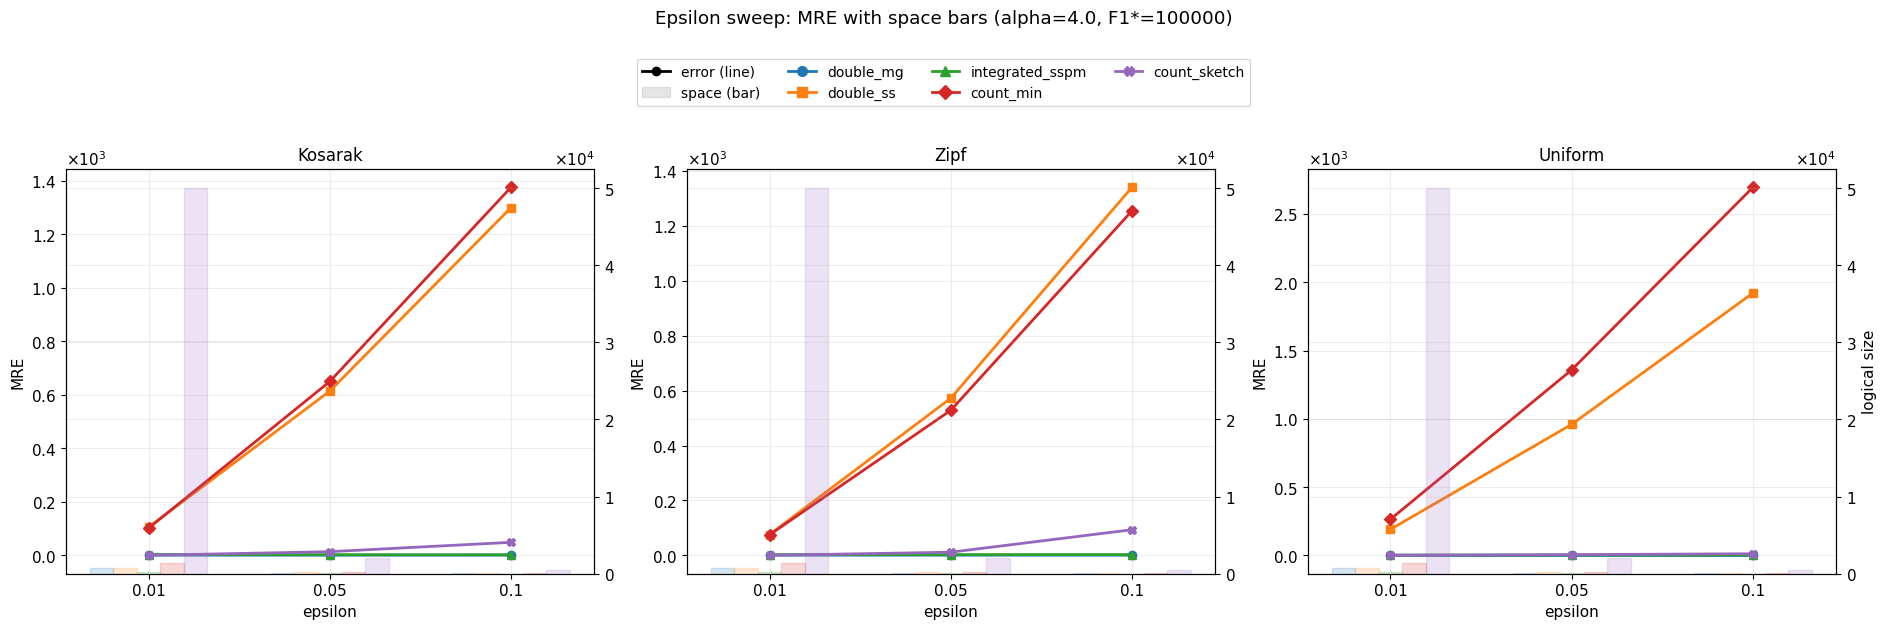

In [56]:
epsilon_f1 = 100000
epsilon_alpha = 4.0  # 可以改成 1.5, 2.0, 3.0, 4.0, 6.0, 8.0
plot_triptych_epsilon(
    epsilon_results,
    final_f1=epsilon_f1,
    alpha=epsilon_alpha,
    error_metric='avg_norm_abs_error',
    space_metric='logical_size',
    save_name=f'epsilon_triptych_error_space_alpha_{str(epsilon_alpha).replace('.', 'p')}_f1_{epsilon_f1}.png',
)
plot_triptych_epsilon(
    epsilon_results,
    final_f1=epsilon_f1,
    alpha=epsilon_alpha,
    error_metric='avg_relative_error',
    space_metric='logical_size',
    save_name=f'epsilon_triptych_relative_error_space_alpha_{str(epsilon_alpha).replace('.', 'p')}_f1_{epsilon_f1}.png',
)

## 3. Equal Logical Space Comparison

固定 `F1*=100000` 和一个 `alpha`，在相同 `logical size` 预算下比较不同算法的 error。

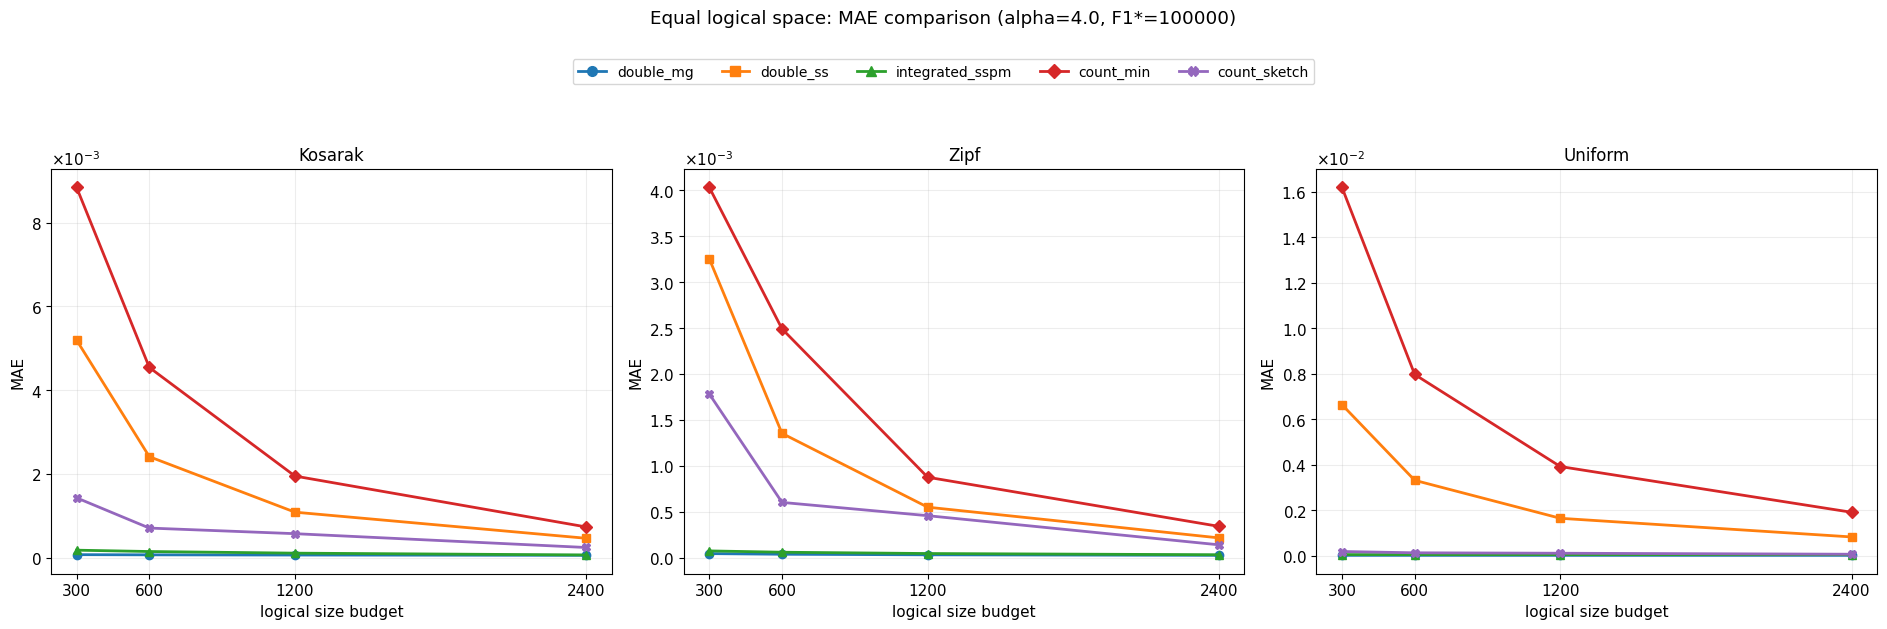

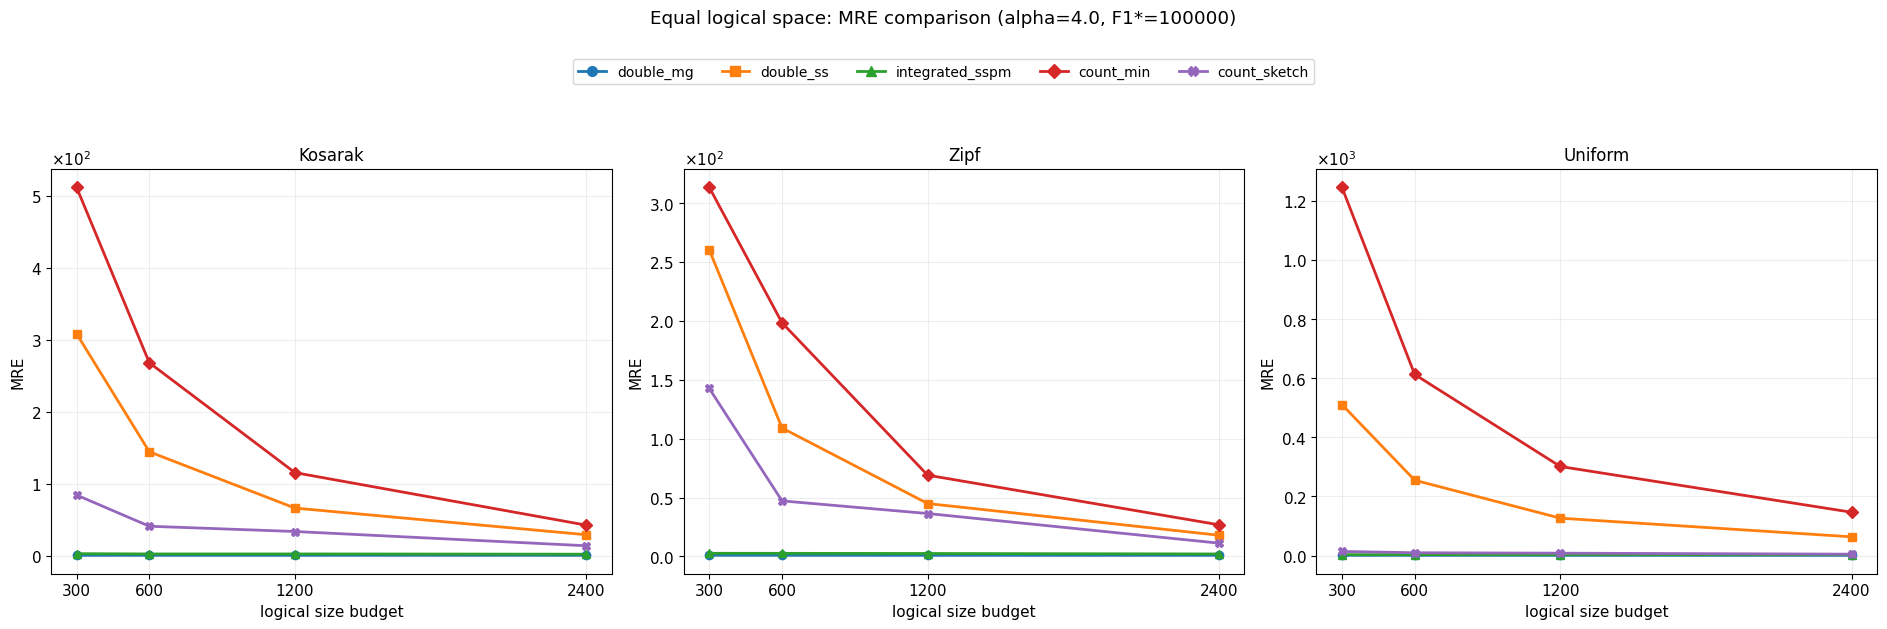

In [57]:
equal_space_f1 = 100000
equal_space_alpha = 4.0  # 可以改成 1.5, 2.0, 3.0, 4.0, 6.0, 8.0
plot_triptych_equal_space(
    equal_space_results,
    final_f1=equal_space_f1,
    alpha=equal_space_alpha,
    error_metric='avg_norm_abs_error',
    save_name=f'equal_space_triptych_error_alpha_{str(equal_space_alpha).replace('.', 'p')}_f1_{equal_space_f1}.png',
)
plot_triptych_equal_space(
    equal_space_results,
    final_f1=equal_space_f1,
    alpha=equal_space_alpha,
    error_metric='avg_relative_error',
    save_name=f'equal_space_triptych_relative_error_alpha_{str(equal_space_alpha).replace('.', 'p')}_f1_{equal_space_f1}.png',
)

### 4.1 Equal Space Alpha Sweep

固定一个 `logical size`，分别比较不同 `alpha` 下的误差变化。

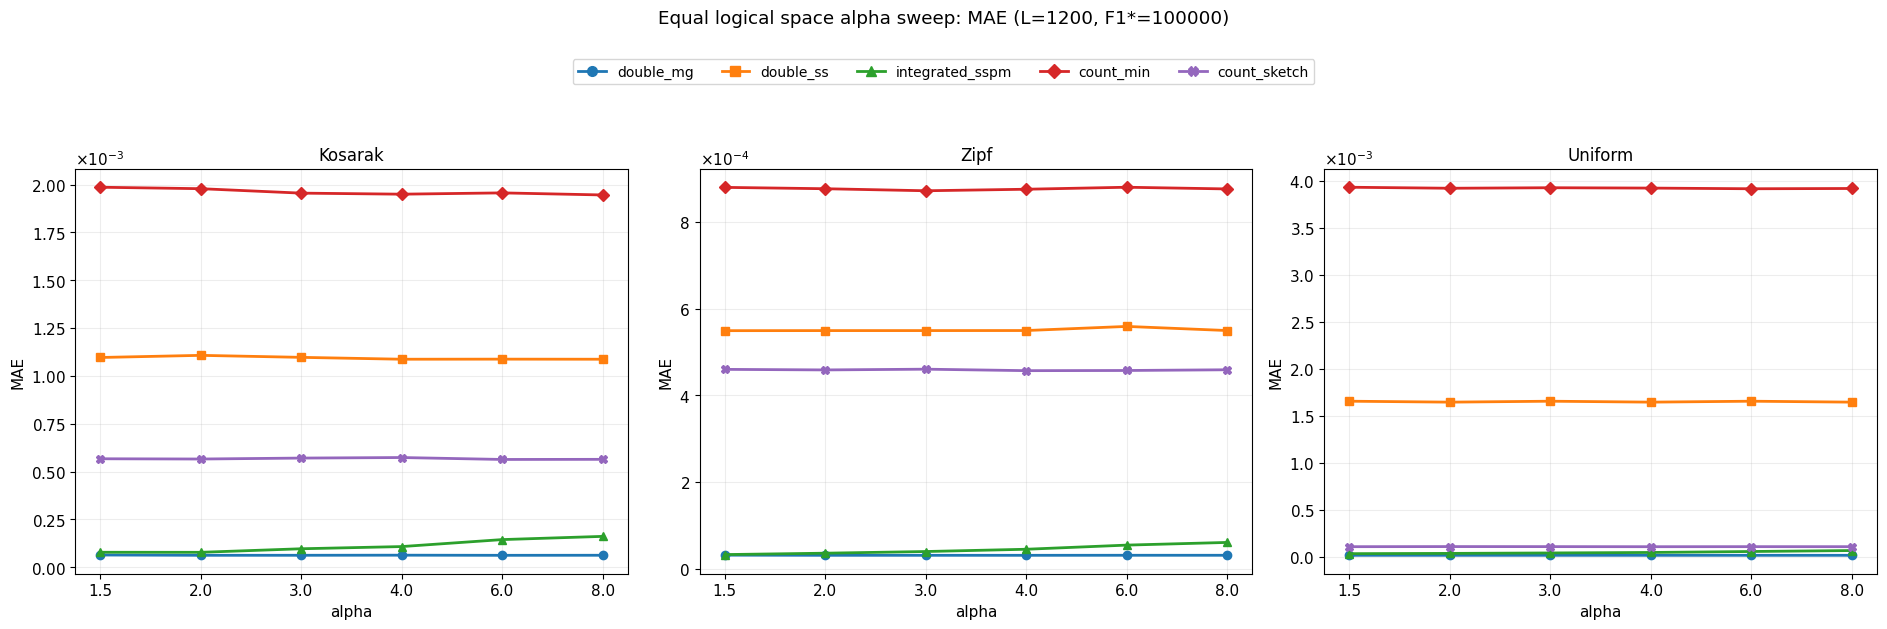

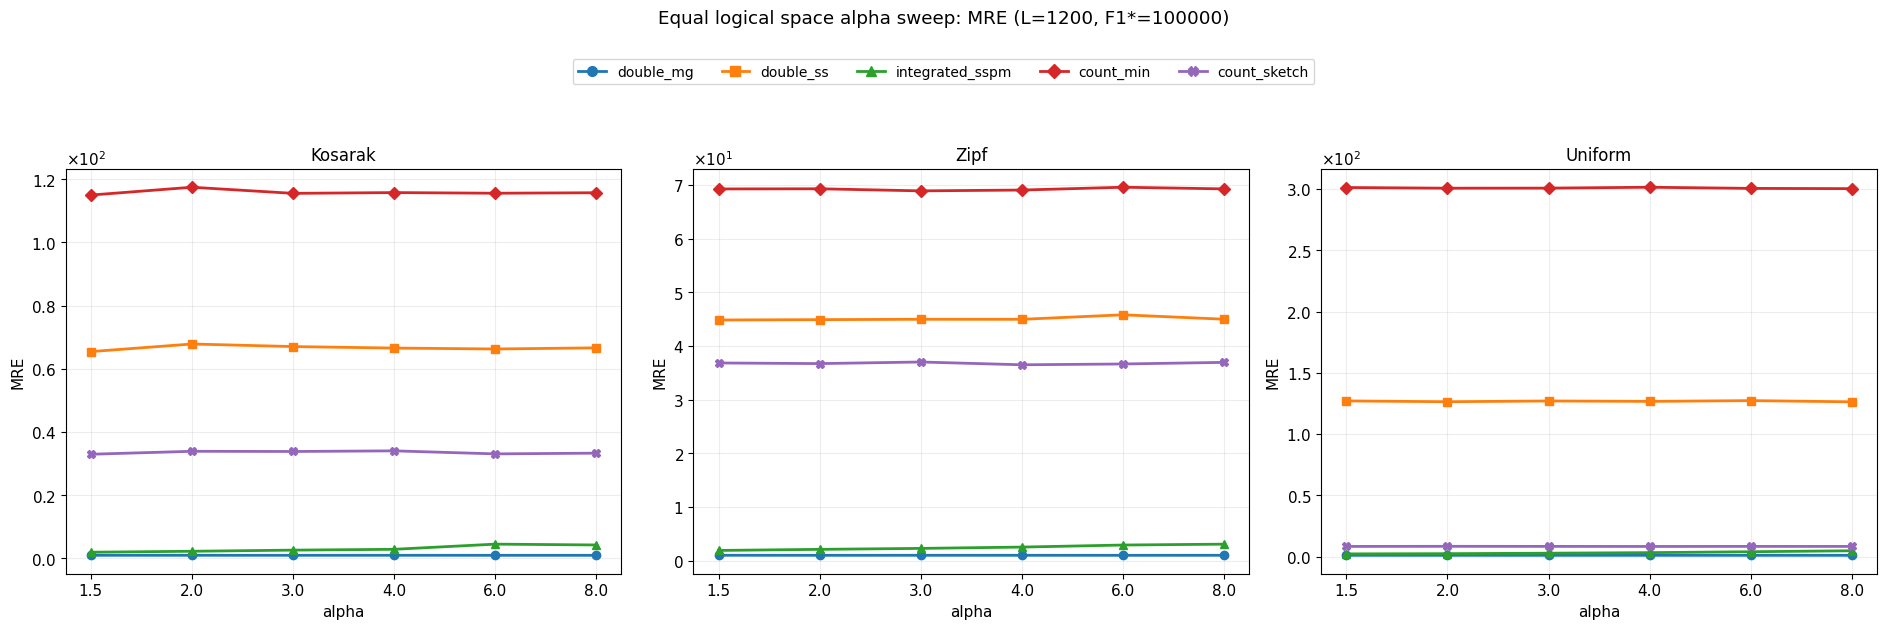

In [58]:
equal_space_alpha_f1 = 100000
equal_space_alpha_budget = 1200  # 可以改成 300, 600, 1200, 2400
plot_triptych_equal_space_alpha(
    equal_space_results,
    logical_size=equal_space_alpha_budget,
    final_f1=equal_space_alpha_f1,
    error_metric='avg_norm_abs_error',
    save_name=f'equal_space_alpha_triptych_L_{int(equal_space_alpha_budget)}_f1_{equal_space_alpha_f1}.png',
)
plot_triptych_equal_space_alpha(
    equal_space_results,
    logical_size=equal_space_alpha_budget,
    final_f1=equal_space_alpha_f1,
    error_metric='avg_relative_error',
    save_name=f'equal_space_alpha_triptych_relative_error_L_{int(equal_space_alpha_budget)}_f1_{equal_space_alpha_f1}.png',
)

### 4.2 Equal Space Stream-Length Sweep

固定一个 `logical size`，分别比较不同 stream length 下的误差变化。

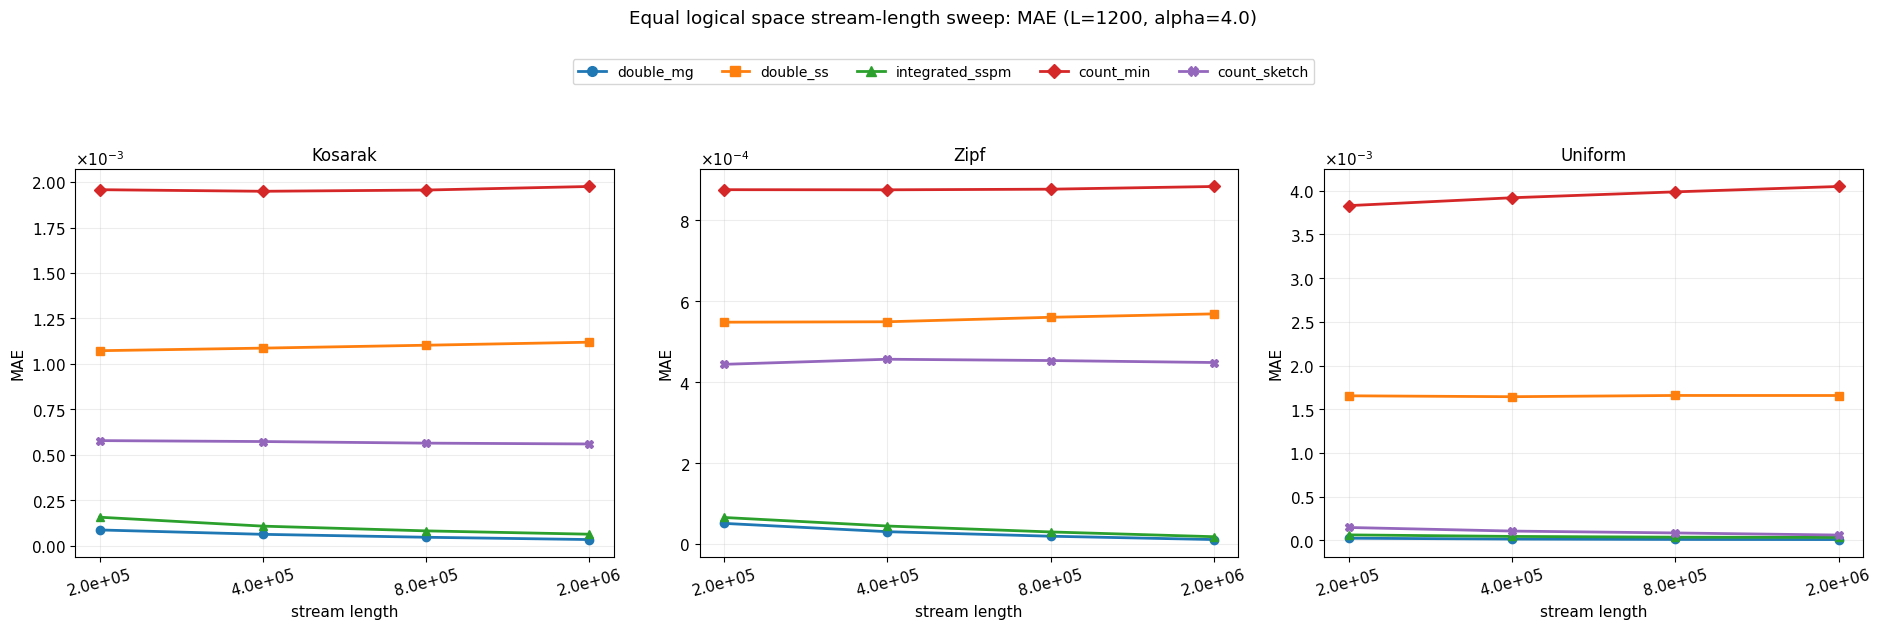

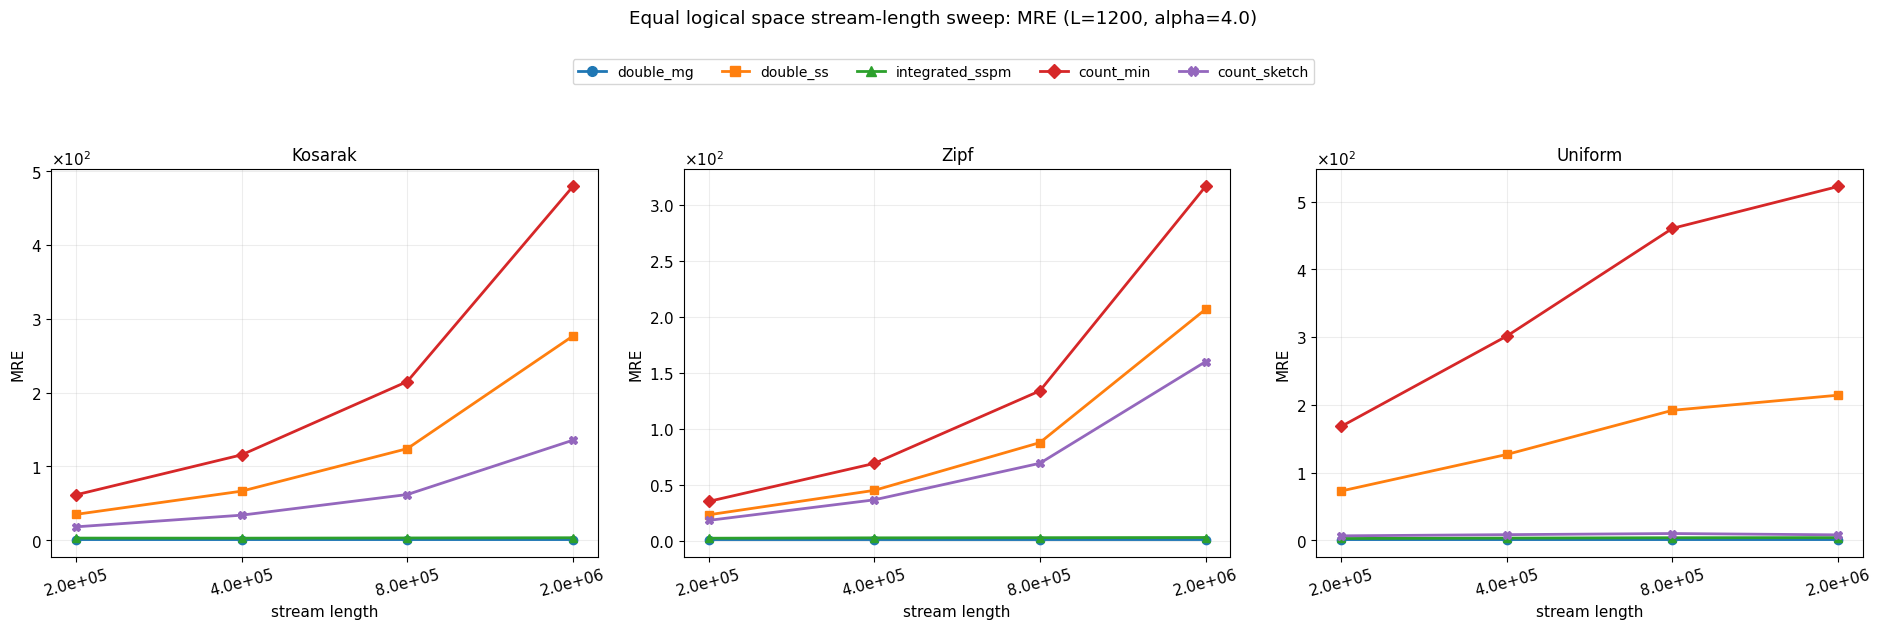

In [59]:
equal_space_stream_alpha = 4.0  # 可以改成 1.5, 2.0, 3.0, 4.0, 6.0, 8.0
equal_space_stream_budget = 1200  # 可以改成 300, 600, 1200, 2400
plot_triptych_equal_space_stream_length(
    equal_space_results,
    logical_size=equal_space_stream_budget,
    alpha=equal_space_stream_alpha,
    error_metric='avg_norm_abs_error',
    save_name=f'equal_space_stream_triptych_L_{int(equal_space_stream_budget)}_alpha_{str(equal_space_stream_alpha).replace('.', 'p')}.png',
)
plot_triptych_equal_space_stream_length(
    equal_space_results,
    logical_size=equal_space_stream_budget,
    alpha=equal_space_stream_alpha,
    error_metric='avg_relative_error',
    save_name=f'equal_space_stream_triptych_relative_error_L_{int(equal_space_stream_budget)}_alpha_{str(equal_space_stream_alpha).replace('.', 'p')}.png',
)

## 5. Tables for the Report

In [ ]:
summary.sort_values(['family', 'alpha', 'algorithm']).head(30)

In [ ]:
pivot_error = results.pivot_table(index=['family', 'alpha', 'final_f1_star'], columns='algorithm', values='avg_norm_abs_error')
pivot_error.round(6)

In [ ]:
pivot_space = results.pivot_table(index=['family', 'alpha', 'final_f1_star'], columns='algorithm', values='logical_size')
pivot_space

In [ ]:
pivot_error.to_csv(ROOT / 'report' / 'tables' / 'project_required_expanded_merged' / 'pivot_error.csv')
pivot_space.to_csv(ROOT / 'report' / 'tables' / 'project_required_expanded_merged' / 'pivot_space.csv')
print('Exported pivot tables to report/tables/project_required_expanded_merged/')